In [1]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append("../../")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import scipy
import pandas as pd
import seaborn as sns
from __future__ import annotations

# from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, make_scorer
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict

from dataclasses import dataclass

import pyaldata as pyal

import tools.dsp as dsp
from tools.params import Params
import tools.dimensionality as dim
import tools.decoding as decode
import tools.subspaces as subspaces
import tools.viz.utilityTools as vizutils
import tools.dataTools as dt
from tools.params import colors
import tools.reports as reports
import tools.kinematics as kin

from tqdm import tqdm
import pickle

from joblib import Parallel, delayed
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.model_selection import cross_validate, KFold, StratifiedKFold, RepeatedStratifiedKFold
from sklearn.naive_bayes import GaussianNB



In [83]:
data_dir='/data/bnd-data/raw/'

SESSIONS = [
    # "M061_2025_03_04_10_00",
    # "M061_2025_03_05_14_00",
    # "M061_2025_03_06_14_00",
    # "M063_2025_03_13_14_00",
    # "M063_2025_03_14_15_30",
    # "M062_2025_03_20_14_00",
    # "M062_2025_03_21_14_00",
    # "M078_2025_08_06_15_00",
    # "M086_2025_12_10_15_00",
    # "M103_2026_02_17_14_00",
    # "M103_2026_02_18_15_30",
    "M103_2026_02_19_15_30",
    # "M106_2026_02_24_15_00",
    # "M106_2026_02_25_15_00",
    # "M106_2026_02_26_16_00",
]


session=SESSIONS[0]

In [84]:
df_ = pyal.load_pyaldata(data_dir + session[:4] + "/" + session)
df_ = dsp.preprocess(
    df_,
    only_trials=False,
    combine_time_bins=False, 
    # repair_time_varying_fields=['MotSen1_X', 'MotSen1_Y']
)

fields: ['values_before_camera_trigger', 'idx_before_camera_trigger', 'values_Sol_direction', 'values_Sol_duration'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_direction', 'values_Sol_duration'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_direction', 'idx_Sol_direction', 'values_Sol_duration', 'idx_Sol_duration', 'idx_sol_on'] could not be converted to int.
['CP_spikes', 'all_spikes', 'MOp_spikes', 'SSp_spikes', 'VAL_spikes']


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of CP_spikes on 99.81343283582089% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of CP_spikes on 99.81343283582089% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of CP_spikes on 99.81343283582089% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of CP_spikes on 99.81343283582089% of trials
  warnings.warn(


Resulting CP_spikes ephys data shape is (NxT): (176, 120000)
Resulting all_spikes ephys data shape is (NxT): (9, 120000)
Resulting MOp_spikes ephys data shape is (NxT): (141, 120000)
Resulting SSp_spikes ephys data shape is (NxT): (92, 120000)
Resulting VAL_spikes ephys data shape is (NxT): (229, 120000)


In [85]:
df__ = dt.add_pca_df(df_)

In [86]:
ALL_BHV_FIELDS = [
    "left_ankle",
    "left_elbow",
    "left_foot",
    "left_knee",
    "left_paw",
    "left_wrist",
    "right_ankle",
    "right_elbow",
    "right_foot",
    "right_knee",
    "right_paw",
    "right_wrist",
]

FORE_KEYWORDS = [
    "wrist",
    "paw",
    "elbow",
]

HIND_KEYWORDS = [
    "foot",
    "ankle",
    "knee",
]


def get_limb(forelimb: bool, laterality: str):
    if forelimb:
        body_parts = FORE_KEYWORDS
    else:
        body_parts = HIND_KEYWORDS

    bhv_fields = [
        field
        for field in ALL_BHV_FIELDS
        if (laterality in field) and any(body_part in field for body_part in body_parts)
    ]
    return bhv_fields

feature_dims = np.arange(start=2, stop=len(ALL_BHV_FIELDS)*3, step=3)


In [94]:
df = dt.add_bhv(df__, bhv_fields=ALL_BHV_FIELDS)
df = dt.concat_previous_intertrial_signal(df, 'bhv', features=feature_dims)

# Compute metric
df = dt.add_concat_perturb_time(df)
df = dt.add_concat_trial_start(df)
df = kin.compute_power_in_bhv_concat_td(df)
df = kin.add_power_metric_to_td(df)

# Select trials and drop nans
df_tr = pyal.select_trials(df, df.trial_name == 'trial')
df_tr = kin.drop_immobile_trials_from_td(df_tr, p=2, win=10, event_onset=(100, 500))
mask = df_tr["disturb_score"].apply(
    lambda x: not np.any(np.isnan(x))
)
df_tr = df_tr.loc[mask]

df_tr['disturb_sum'] = df_tr['disturb_score'].apply(lambda a: np.log10(np.abs(np.sum(a))))

# Add instantaneous phase
disturbances = np.sum(np.stack(df_tr.disturb_score.values), axis=1)
dstrb_idx = np.argsort(disturbances)


Skipped 19 trials
d: 1.776
Bimodal: False
Thresh: 0.77
Dropped 12 of 267 rows (4.49%).


TypeError: ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

In [8]:
### go from here

df_design = df_tr.copy()
perturb_td = pyal.restrict_to_interval(df_design, 'idx_sol_on', rel_start = -200, rel_end = 300)
perturb_td_shuff = perturb_td.sample(frac=1, random_state=42).reset_index(drop=False)

In [ ]:
AREAS = [
    c.replace('_rates_pca', '')
    for c in df.columns
    if c.endswith('_rates_pca') and not c.startswith('MOp') and c != 'GPe_rates_pca'
]
print("Target areas:", AREAS)

Target areas: ['CP', 'VAL', 'SSp']


In [11]:
from tools.subspaces.regression import cross_val_semedo_rrr, get_opt_rank
from tools.subspaces.communication import compute_embedding_on_td

WINDOW = (0, 190)
RANK_LIST = np.arange(1, 31)

# Per-area Y truncation for rank CV
TARGET_RANKS = {'SSp': 20, 'VAL': 50, 'CP': 30}

# Auto-detect target areas, excluding MOp and GPe
AREAS = [
    c.replace('_rates_pca', '')
    for c in perturb_td_shuff.columns
    if c.endswith('_rates_pca') and not c.startswith('MOp') and c != 'GPe_rates_pca'
]
print("Target areas:", AREAS)

# --- Semedo rank optimisation on FULL (non-windowed) trial data ---
# Rank is optimised on all time bins; embeddings are later computed on WINDOW only
optimal_ranks = {}

for area in AREAS:
    target_rank = TARGET_RANKS[area]
    X_full = np.concatenate(perturb_td_shuff['MOp_rates_pca'].values)
    Y_full = np.concatenate(perturb_td_shuff[f'{area}_rates_pca'].values)[:, :target_rank]

    _, opt_rank = cross_val_semedo_rrr(
        X_full, Y_full, alpha=100, fit_rank=True, ranks=RANK_LIST
    )
    optimal_ranks[area] = int(opt_rank)
    print(f"  {area}: opt_rank = {opt_rank}  (target_rank={target_rank})")

# --- Also optimise rank for MOp → bhv (motor potent subspace) ---
X_full = np.concatenate(perturb_td_shuff['MOp_rates_pca'].values)
Y_full = np.concatenate(perturb_td_shuff['bhv'].values)[:, feature_dims]  # z-dims only

_, opt_rank_bhv = cross_val_semedo_rrr(
    X_full, Y_full, alpha=100, fit_rank=True, ranks=RANK_LIST
)
optimal_ranks['bhv'] = int(opt_rank_bhv)
print(f"  bhv (z-dims): opt_rank = {opt_rank_bhv}")
print(f"\nAll optimal ranks: {optimal_ranks}")


NameError: name 'perturb_td_shuff' is not defined

## Build pseudo-trials: Free locomotion vs Intertrial

Slice the continuous free-locomotion and intertrial recordings into non-overlapping **250-bin (2.5 s) chunks**.  
This matches the analysis window used for perturbation trials, making conditions directly comparable.  
The same `optimal_ranks` derived from perturbation data are reused throughout.

Immobile chunks (mean L2 speed of z-dim velocity < p5 of the combined distribution) are discarded before balancing.

In [95]:
def build_pseudo_trials(td_rows, chunk_size, fields):
    """Slice each row into non-overlapping chunks of `chunk_size` bins."""
    rows = []
    for _, trial in td_rows.iterrows():
        n_bins  = trial[fields[0]].shape[0]
        n_chunks = n_bins // chunk_size
        for k in range(n_chunks):
            sl = slice(k * chunk_size, (k + 1) * chunk_size)
            chunk = {}
            valid = True
            for f in fields:
                arr = trial[f][sl]
                if np.isnan(arr).any():
                    valid = False
                    break
                chunk[f] = arr
            if valid:
                rows.append(chunk)
    return pd.DataFrame(rows)
# AREAS = Params.areas
WINDOW = (200, 450)
CHUNK_SIZE = WINDOW[1] - WINDOW[0]      # 250 bins — same as analysis window
FREE_WINDOW   = (0, CHUNK_SIZE)
fields_needed = ['MOp_rates_pca', 'bhv'] + [f'{a}_rates_pca' for a in AREAS]

# Show what trial_name values exist and which is the free row
print("trial_name counts in df:")
print(df.trial_name.value_counts().to_string())
print()

# --- Free locomotion: first (or early) rows that are not 'trial' or 'intertrial' ---
df_free_rows = df[~df.trial_name.isin(['trial', 'intertrial'])]
if len(df_free_rows) == 0:
    df_free_rows = df.iloc[[0]]
    print(f"No non-trial/intertrial rows found; using first row (trial_name='{df.iloc[0].trial_name}')")
else:
    df_free_rows = df_free_rows.iloc[[0]]

free_td = build_pseudo_trials(df_free_rows, CHUNK_SIZE, fields_needed)
print(f"Free loco source rows : {len(df_free_rows)}  →  pseudo-trials: {len(free_td)}")

# --- Intertrial (pre-perturbation / between perturbations) ---
df_it = pyal.select_trials(df, df.trial_name == 'intertrial')
intertrial_td = build_pseudo_trials(df_it, CHUNK_SIZE, fields_needed)
print(f"Intertrial source rows: {len(df_it)}  →  pseudo-trials: {len(intertrial_td)}")

# --- Balance: subsample both to the same count ---
N_PSEUDO = min(len(free_td), len(intertrial_td))
print(f"\nBalancing to {N_PSEUDO} pseudo-trials per condition")

free_td_shuff       = free_td.sample(n=N_PSEUDO, random_state=42).reset_index(drop=True)
intertrial_td_shuff = intertrial_td.sample(n=N_PSEUDO, random_state=42).reset_index(drop=True)


trial_name counts in df:
trial_name
intertrial    267
trial         267
free            2

Free loco source rows : 1  →  pseudo-trials: 480
Intertrial source rows: 267  →  pseudo-trials: 266

Balancing to 266 pseudo-trials per condition


## Fixed-W_motor overlap: XYZ position — Free vs Intertrial

W_motor estimated from all-keypoint xyz positions (`bhv`, `optimal_ranks['bhv']=4`).  
Null = shuffle area signal per condition, W_motor held fixed.  
Grassmannian baseline = max cos² over 10 000 random rank-k subspace pairs in d=178 MOp PCs.

In [32]:

# ── Fixed-W_motor (within-condition) approach ─────────────────────────────────
# For each condition:
#   1. Estimate W_motor from that condition's MOp→bhv_signal  (fixed for the null)
#      using the rank optimised specifically for that signal  (optimal_ranks['bhv'])
#   2. Estimate W_comm from that condition's MOp→area  (observed)
#   3. Null: keep W_motor fixed, shuffle area-signal rows → re-estimate W_comm

def run_fixed_motor_within_cond(td_shuff, window, area_list, opt_ranks, n_perms, label,
                                 bhv_signal='bhv'):
    res = {}

    # --- W_motor estimated once per condition ---
    bhv_rank = opt_ranks[bhv_signal]
    W_motor_cond, _ = compute_embedding_on_td(
        td_shuff,
        signal_x='MOp_rates_pca',
        signal_y=bhv_signal,
        model=subspaces.ReducedRankCommSubspace(rank=bhv_rank),
        window=window,
    )
    print(f"[{label}] W_motor ({bhv_signal}) estimated  (rank={bhv_rank},  shape={W_motor_cond.shape})")

    for area in area_list:
        opt_rank = opt_ranks[area]

        # --- Observed W_comm ---
        W_comm_obs, _ = compute_embedding_on_td(
            td_shuff,
            signal_x='MOp_rates_pca',
            signal_y=f'{area}_rates_pca',
            model=subspaces.ReducedRankCommSubspace(rank=opt_rank),
            window=window,
        )
        obs = subspaces.compute_overlap_between_subspaces(W_motor_cond, W_comm_obs)

        # --- Null: shuffle area signal, keep W_motor fixed ---
        # Use default arg to capture area/opt_rank/W_motor_cond by value (avoid closure bug)
        area_sig = td_shuff[f'{area}_rates_pca'].values.copy()

        def _one_perm(seed, _area_sig=area_sig, _opt_rank=opt_rank, _W_motor=W_motor_cond):
            rng_ = np.random.default_rng(seed)
            td_perm = td_shuff.copy()
            td_perm[f'{area}_rates_pca'] = _area_sig[rng_.permutation(len(td_shuff))]
            W_c_null, _ = compute_embedding_on_td(
                td_perm,
                signal_x='MOp_rates_pca',
                signal_y=f'{area}_rates_pca',
                model=subspaces.ReducedRankCommSubspace(rank=_opt_rank),
                window=window,
            )
            return subspaces.compute_overlap_between_subspaces(_W_motor, W_c_null)

        null = np.array(Parallel(n_jobs=-1, prefer='threads')(
            delayed(_one_perm)(seed)
            for seed in tqdm(range(n_perms), desc=f'{label} | {area}', leave=True)
        ))

        p = np.mean(null >= obs)
        z = (obs - null.mean()) / null.std()
        print(f"[{label}] {area} (rank={opt_rank})  obs={obs:.4f}  null={null.mean():.4f}±{null.std():.4f}  z={z:.2f}  p={p:.4f}")
        res[area] = dict(overlap=obs, null=null, p=p, z=z, opt_rank=opt_rank, bhv_rank=bhv_rank)
    return res

N_PERMS = 20
optimal_ranks = {
    'SSp': 5,
    'CP': 8,
    'VAL': 10,
    'bhv': 5
}
results_free_fixed       = run_fixed_motor_within_cond(free_td_shuff,       FREE_WINDOW, AREAS, optimal_ranks, N_PERMS, 'Free')
results_intertrial_fixed = run_fixed_motor_within_cond(intertrial_td_shuff, FREE_WINDOW, AREAS, optimal_ranks, N_PERMS, 'Intertrial')


[Free] W_motor (bhv) estimated  (rank=5,  shape=(160, 5))


Free | CP: 100%|██████████| 20/20 [00:00<00:00, 65382.76it/s]


[Free] CP (rank=8)  obs=0.2653  null=0.1210±0.0159  z=9.06  p=0.0000


Free | SSp: 100%|██████████| 20/20 [00:00<00:00, 63310.25it/s]


[Free] SSp (rank=5)  obs=0.2994  null=0.0916±0.0179  z=11.64  p=0.0000


...

[Intertrial] CP (rank=8)  obs=0.1686  null=0.0658±0.0183  z=5.62  p=0.0000


Intertrial | SSp: 100%|██████████| 20/20 [00:00<00:00, 64035.18it/s]


[Intertrial] SSp (rank=5)  obs=0.2450  null=0.0405±0.0112  z=18.32  p=0.0000


Intertrial | VAL: 100%|██████████| 20/20 [00:00<00:00, 67814.13it/s]


[Intertrial] VAL (rank=10)  obs=0.2475  null=0.0772±0.0106  z=16.08  p=0.0000


In [33]:

# ── Grassmannian null: baseline cos² between random rank-k subspaces in MOp ──
# d = number of MOp PCs (the full ambient space both W_motor and W_comm live in)
# For each area: draw W1 ~ Uniform(Grass(d, k_bhv)) and W2 ~ Uniform(Grass(d, k_area))
# Analytical expectation: min(k1, k2) / d

d = df['MOp_rates_pca'].iloc[0].shape[1]  # number of MOp PCs
print(f"MOp PCA dimensionality (d) = {d}")
print(f"Ranks — bhv: {optimal_ranks['bhv']}, areas: { {a: optimal_ranks[a] for a in AREAS} }")
print()

N_GRASS = 10000
rng_gr  = np.random.default_rng(42)

grassmannian_nulls = {}
for area in AREAS:
    k_bhv  = optimal_ranks['bhv']
    k_area = optimal_ranks[area]
    analytical = min(k_bhv, k_area) / d

    nulls = []
    for _ in range(N_GRASS):
        W1, _ = np.linalg.qr(rng_gr.standard_normal((d, k_bhv)))
        W2, _ = np.linalg.qr(rng_gr.standard_normal((d, k_area)))
        nulls.append(subspaces.compute_overlap_between_subspaces(W1, W2))
    nulls = np.array(nulls)
    grassmannian_nulls[area] = nulls

    print(f"  {area}  k_bhv={k_bhv}, k_area={k_area}  |  "
          f"analytical={analytical:.4f}  sim={nulls.mean():.4f}±{nulls.std():.4f}")


MOp PCA dimensionality (d) = 160
Ranks — bhv: 5, areas: {'CP': 8, 'SSp': 5, 'VAL': 10}

  CP  k_bhv=5, k_area=8  |  analytical=0.0312  sim=0.0499±0.0108
  SSp  k_bhv=5, k_area=5  |  analytical=0.0312  sim=0.0313±0.0085
  VAL  k_bhv=5, k_area=10  |  analytical=0.0312  sim=0.0627±0.0120


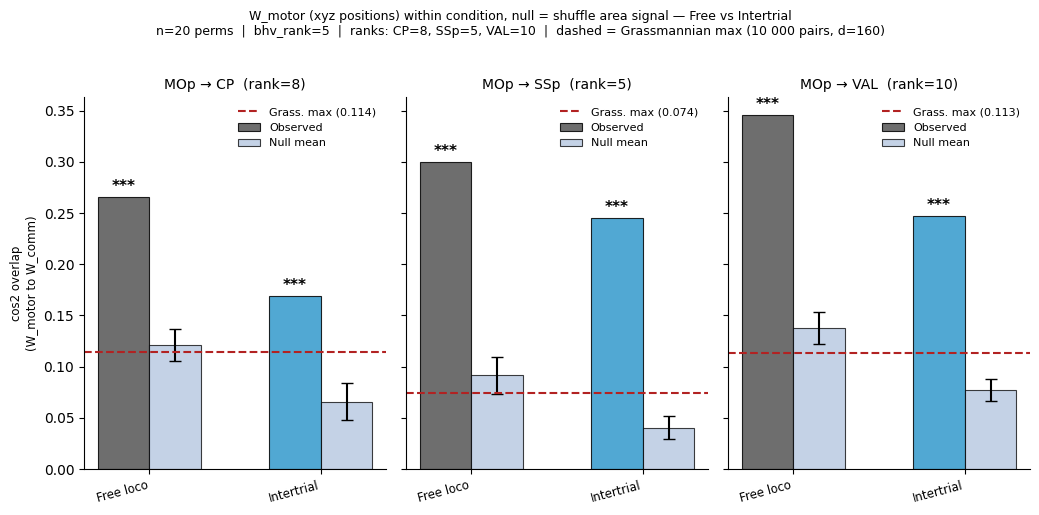

In [34]:

# --- Plot ---
CONDITIONS   = ['Free loco', 'Intertrial']
results_list = [results_free_fixed, results_intertrial_fixed]
cond_colors  = ['#555555', '#3399cc']

fig, axes = plt.subplots(1, len(AREAS), figsize=(3.5 * len(AREAS), 5), sharey=True)

for ax, area in zip(axes, AREAS):
    obs_vals = [res[area]['overlap']    for res in results_list]
    null_m   = [res[area]['null'].mean() for res in results_list]
    null_s   = [res[area]['null'].std()  for res in results_list]
    ps       = [res[area]['p']           for res in results_list]
    zs       = [res[area]['z']           for res in results_list]

    x = np.arange(len(CONDITIONS))
    w = 0.3

    ax.bar(x - w/2, obs_vals, w, color=cond_colors, alpha=0.85, edgecolor='k', lw=0.8, label='Observed')
    ax.bar(x + w/2, null_m,   w, color='lightsteelblue', alpha=0.75, edgecolor='k', lw=0.8, label='Null mean')
    ax.errorbar(x + w/2, null_m, yerr=null_s, fmt='none', color='k', capsize=4, lw=1.5)

    # Grassmannian max
    grass_max = grassmannian_nulls[area].max()
    ax.axhline(grass_max, color='firebrick', lw=1.5, ls='--',
               label=f'Grass. max ({grass_max:.3f})')

    for i, (ob, p, z) in enumerate(zip(obs_vals, ps, zs)):
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.'))
        ax.text(x[i] - w/2, ob + 0.003, sig, ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(CONDITIONS, fontsize=8.5, rotation=15, ha='right')
    ax.set_title(f"MOp → {area}  (rank={optimal_ranks[area]})", fontsize=10)
    ax.set_ylabel("cos2 overlap\n(W_motor to W_comm)" if area == AREAS[0] else "", fontsize=8.5)
    ax.legend(fontsize=8, frameon=False)
    sns.despine(ax=ax)

plt.suptitle(
    f"W_motor (xyz positions) within condition, null = shuffle area signal — Free vs Intertrial\n"
    f"n={N_PERMS} perms  |  bhv_rank={optimal_ranks['bhv']}  |  "
    f"ranks: {', '.join(f'{a}={optimal_ranks[a]}' for a in AREAS)}"
    f"  |  dashed = Grassmannian max (10 000 pairs, d={df['MOp_rates_pca'].iloc[0].shape[1]})",
    fontsize=9, y=1.02,
)
plt.tight_layout()
plt.show()


## Motor potent subspace: XYZ velocity (36 dims)

Same fixed-W_motor approach as above, but W_motor is estimated from the **velocity** of all 12 keypoints (finite-difference of xyz positions → 36 dims per time bin).
The window shifts to `(0, CHUNK_SIZE-1)` because differencing reduces T by 1.

In [ ]:

# ── Fixed-W_motor: ALL-keypoint velocity (finite-difference xyz) ──────────────
# Same approach as xyz-position analysis but W_motor is estimated from the
# velocity of all 12 keypoints (all 3 dims → 36 velocity dims per time bin).
# Velocity reduces T by 1 → use VEL_WINDOW = (0, CHUNK_SIZE-1).

ALL_VEL_WINDOW = (0, CHUNK_SIZE - 1)

# --- Compute all-keypoint velocity and attach to pseudo-trial tables ---
for td in [free_td_shuff, intertrial_td_shuff]:
    td['bhv_vel'] = [np.diff(row, axis=0) for row in td['bhv'].values]  # (T-1, 36)

# --- Use the same rank as xyz-position bhv (rank=4) to avoid rank-1 degeneracy ---
optimal_ranks['bhv_vel'] = optimal_ranks['bhv']   # reuse rank optimised for xyz positions
print(f"bhv_vel rank set to optimal_ranks['bhv'] = {optimal_ranks['bhv_vel']}")
print(f"Updated optimal_ranks: {optimal_ranks}")

# --- Run fixed-W_motor overlap analysis ---
N_PERMS_VEL = 20

results_free_vel       = run_fixed_motor_within_cond(
    free_td_shuff,       ALL_VEL_WINDOW, AREAS, optimal_ranks, N_PERMS_VEL, 'Free',
    bhv_signal='bhv_vel')
results_intertrial_vel = run_fixed_motor_within_cond(
    intertrial_td_shuff, ALL_VEL_WINDOW, AREAS, optimal_ranks, N_PERMS_VEL, 'Intertrial',
    bhv_signal='bhv_vel')

# --- Grassmannian null for bhv_vel ranks ---
d_vel = free_td_shuff['MOp_rates_pca'].iloc[0].shape[1]
rng_gr_vel = np.random.default_rng(0)
grass_vel = {}
for area in AREAS:
    k1, k2 = optimal_ranks['bhv_vel'], optimal_ranks[area]
    nulls = []
    for _ in range(10_000):
        W1, _ = np.linalg.qr(rng_gr_vel.standard_normal((d_vel, k1)))
        W2, _ = np.linalg.qr(rng_gr_vel.standard_normal((d_vel, k2)))
        nulls.append(subspaces.compute_overlap_between_subspaces(W1, W2))
    grass_vel[area] = max(nulls)
    print(f"  {area}  k_bhv_vel={k1}, k_area={k2}  grass_max={grass_vel[area]:.4f}")

# --- Plot ---
CONDITIONS_VEL   = ['Free loco', 'Intertrial']
results_list_vel = [results_free_vel, results_intertrial_vel]
cond_colors_vel  = ['#555555', '#3399cc']

fig, axes = plt.subplots(1, len(AREAS), figsize=(3.5 * len(AREAS), 5), sharey=True)

for ax, area in zip(axes, AREAS):
    obs_vals = [res[area]['overlap']    for res in results_list_vel]
    null_m   = [res[area]['null'].mean() for res in results_list_vel]
    null_s   = [res[area]['null'].std()  for res in results_list_vel]
    ps       = [res[area]['p']           for res in results_list_vel]
    zs       = [res[area]['z']           for res in results_list_vel]

    x = np.arange(len(CONDITIONS_VEL))
    w = 0.3

    ax.bar(x - w/2, obs_vals, w, color=cond_colors_vel, alpha=0.85, edgecolor='k', lw=0.8, label='Observed')
    ax.bar(x + w/2, null_m,   w, color='lightsteelblue', alpha=0.75, edgecolor='k', lw=0.8, label='Null mean')
    ax.errorbar(x + w/2, null_m, yerr=null_s, fmt='none', color='k', capsize=4, lw=1.5)

    ax.axhline(grass_vel[area], color='firebrick', lw=1.5, ls='--',
               label=f'Grass. max ({grass_vel[area]:.3f})')

    for i, (ob, p, z) in enumerate(zip(obs_vals, ps, zs)):
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.'))
        ax.text(x[i] - w/2, ob + 0.003, sig, ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(CONDITIONS_VEL, fontsize=8.5, rotation=15, ha='right')
    ax.set_title(f"MOp → {area}  (rank={optimal_ranks[area]})", fontsize=10)
    ax.set_ylabel("cos² overlap\n(W_motor to W_comm)" if area == AREAS[0] else "", fontsize=8.5)
    ax.legend(fontsize=8, frameon=False)
    sns.despine(ax=ax)

plt.suptitle(
    f"W_motor from ALL-keypoint velocity (36 dims) — Free vs Intertrial\n"
    f"n={N_PERMS_VEL} perms  |  bhv_vel_rank={optimal_ranks['bhv_vel']}  |  "
    f"ranks: {', '.join(f'{a}={optimal_ranks[a]}' for a in AREAS)}"
    f"  |  dashed = Grassmannian max (10 000 pairs, d={d_vel})",
    fontsize=9, y=1.02,
)
plt.tight_layout()
plt.show()


## Motor potent subspace: XYZ position + velocity + joint angles (80 dims)

`bhv_ext[t] = [position(t+1, 36 dims), velocity(t→t+1, 36 dims), angles(t+1, 8 dims)]`  
This 80-dim representation captures posture, movement, and joint geometry jointly.  
Pseudo-trials are rebuilt with angle columns included; the same immobility filter is applied.  
W_motor rank is re-optimised via cross-validated RRR on perturbation data.

In [91]:
df_free_rows.head()

,animal,session,trial_id,trial_name,trial_length,bin_size,idx_trial_start,idx_trial_end,idx_CPI,values_before_camera_trigger,...,MOp_rates_pca,VAL_rates_pca,SSp_rates_pca,bhv,bhv_concat,concat_perturb_time,concat_trial_start,power,phases,disturb_score
0,M103,M103_2026_02_18_15_30,0,free,48000,0.01,0,47999,[],1,...,"[[-8.447412, -36.748703, 8.974495, 7.4814496, ...","[[91.12041, -108.87979, -13.493584, 28.11036, ...","[[16.662294, -2.2415242, -34.87369, -12.453446...","[[9.94964792308344, 10.471702392454532, 200.33...",None,None,None,None,None,None


In [97]:

# ── Fixed-W_motor: XYZ position + velocity + joint angles (80 dims) ───────────
# bhv_ext[t] = [position(t+1), velocity(t→t+1), angles(t+1)]
#            = 36 xyz + 36 vel + 8 angles → T-1 bins × 80 dims
#
# Joint angle fields are separate scalar columns in df (not part of bhv).
# Strategy: rebuild pseudo-trials including angle fields from same source,
# filter with same L2-norm speed metric → thresh_imm, balance to N_EXT.

ANGLE_FIELDS = [
    'left_ankle_angle', 'left_elbow_angle', 'left_knee_angle', 'left_wrist_angle',
    'right_ankle_angle', 'right_elbow_angle', 'right_knee_angle', 'right_wrist_angle',
]
ALL_VEL_WINDOW = (0, CHUNK_SIZE - 1)
EXT_WINDOW = ALL_VEL_WINDOW   # (0, CHUNK_SIZE-1)

# --- Rebuild pseudo-trial tables with angle columns included ---
fields_with_angles = fields_needed + ANGLE_FIELDS

free_td_ext_raw       = build_pseudo_trials(df_free_rows, CHUNK_SIZE, fields_with_angles)
intertrial_td_ext_raw = build_pseudo_trials(df_it,        CHUNK_SIZE, fields_with_angles)
print(f"Free pseudo-trials (raw): {len(free_td_ext_raw)}")
print(f"Intertrial pseudo-trials (raw): {len(intertrial_td_ext_raw)}")

# --- Immobile filter: same metric as original (mean L2 norm of z-dim velocity) ---
z_cols = np.arange(2, len(ALL_BHV_FIELDS) * 3, 3)   # z-dim indices in bhv

def trial_mean_speed(td_row):
    vel_z = np.diff(td_row['bhv'][:, z_cols], axis=0)  # (T-1, 12)
    return np.mean(np.linalg.norm(vel_z, axis=1))

sf_ext = np.array([trial_mean_speed(r) for _, r in free_td_ext_raw.iterrows()])
si_ext = np.array([trial_mean_speed(r) for _, r in intertrial_td_ext_raw.iterrows()])

# Compute immobility threshold: p=5 percentile of combined speed distribution
thresh_imm = np.percentile(np.concatenate([sf_ext, si_ext]), 5)
print(f"Immobility threshold (p=5): {thresh_imm:.3f}")

free_td_ext       = free_td_ext_raw[sf_ext >= thresh_imm].reset_index(drop=True)
intertrial_td_ext = intertrial_td_ext_raw[si_ext >= thresh_imm].reset_index(drop=True)
print(f"After immobile filter (thresh={thresh_imm:.3f}): Free={len(free_td_ext)}, IT={len(intertrial_td_ext)}")

N_EXT = min(len(free_td_ext), len(intertrial_td_ext), N_PSEUDO)
print(f"Balancing to N={N_EXT} pseudo-trials")

free_td_ext_shuff       = free_td_ext.sample(n=N_EXT, random_state=42).reset_index(drop=True)
intertrial_td_ext_shuff = intertrial_td_ext.sample(n=N_EXT, random_state=42).reset_index(drop=True)

# --- Build bhv_ext: position + velocity + angles → (T-1, 80) ---
def make_bhv_ext(td_row):
    pos = td_row['bhv']                                        # (T, 36)
    vel = np.diff(pos, axis=0)                                 # (T-1, 36)
    ang = np.column_stack([td_row[f][1:] for f in ANGLE_FIELDS])  # (T-1, 8)
    return np.concatenate([pos[1:, :], vel, ang], axis=1)      # (T-1, 80)

for td in [free_td_ext_shuff, intertrial_td_ext_shuff]:
    td['bhv_ext'] = [make_bhv_ext(row) for _, row in td.iterrows()]

# --- Build bhv_ext for perturb_td_shuff (for rank CV) ---
bhv_ext_perturb = []
mop_ext_perturb = []
for _, row in df.iterrows():
    pos = row['bhv']
    vel = np.diff(pos, axis=0)
    ang = np.column_stack([row[f][1:] for f in ANGLE_FIELDS])
    bhv_ext_perturb.append(np.concatenate([pos[1:, :], vel, ang], axis=1))
    mop_ext_perturb.append(row['MOp_rates_pca'][1:, :])

X_full_ext = np.concatenate(mop_ext_perturb)[:400000, :]
Y_full_ext = np.concatenate(bhv_ext_perturb)[:400000, :]
print(f"bhv_ext dims: {Y_full_ext.shape[1]}  (expected 80)")

_, opt_rank_ext = cross_val_semedo_rrr(
    X_full_ext, Y_full_ext, alpha=100, fit_rank=True, ranks=RANK_LIST
)
optimal_ranks['bhv_ext'] = int(opt_rank_ext)
print(f"Optimal rank for MOp → bhv_ext (pos+vel+angles): {opt_rank_ext}")
print(f"All optimal_ranks: {optimal_ranks}")

# --- Run fixed-W_motor overlap analysis ---
N_PERMS_EXT = 20

results_free_ext       = run_fixed_motor_within_cond(
    free_td_ext_shuff,       EXT_WINDOW, AREAS, optimal_ranks, N_PERMS_EXT, 'Free',
    bhv_signal='bhv_ext')
results_intertrial_ext = run_fixed_motor_within_cond(
    intertrial_td_ext_shuff, EXT_WINDOW, AREAS, optimal_ranks, N_PERMS_EXT, 'Intertrial',
    bhv_signal='bhv_ext')

# --- Grassmannian null ---
d_ext      = free_td_ext_shuff['MOp_rates_pca'].iloc[0].shape[1]
rng_gr_ext = np.random.default_rng(0)
grass_ext  = {}
for area in AREAS:
    k1, k2 = optimal_ranks['bhv_ext'], optimal_ranks[area]
    nulls = []
    for _ in range(10_000):
        W1_, _ = np.linalg.qr(rng_gr_ext.standard_normal((d_ext, k1)))
        W2_, _ = np.linalg.qr(rng_gr_ext.standard_normal((d_ext, k2)))
        nulls.append(subspaces.compute_overlap_between_subspaces(W1_, W2_))
    grass_ext[area] = max(nulls)
    print(f"  {area}  k_bhv_ext={k1}, k_area={k2}  grass_max={grass_ext[area]:.4f}")


Free pseudo-trials (raw): 480
Intertrial pseudo-trials (raw): 266
Immobility threshold (p=5): 3.058
After immobile filter (thresh=3.058): Free=477, IT=231
Balancing to N=231 pseudo-trials


bhv_ext dims: 80  (expected 80)
Optimal rank for MOp → bhv_ext (pos+vel+angles): 2
All optimal_ranks: {'SSp': 5, 'CP': 8, 'VAL': 10, 'bhv': 5, 'bhv_ext': 2}
[Free] W_motor (bhv_ext) estimated  (rank=2,  shape=(141, 2))


Free | CP: 100%|██████████| 20/20 [00:00<00:00, 58950.16it/s]


[Free] CP (rank=8)  obs=0.3465  null=0.2742±0.0240  z=3.01  p=0.0000


Free | VAL: 100%|██████████| 20/20 [00:00<00:00, 80273.76it/s]


...

[Intertrial] CP (rank=8)  obs=0.2122  null=0.0838±0.0206  z=6.24  p=0.0000


Intertrial | VAL: 100%|██████████| 20/20 [00:00<00:00, 81760.31it/s]


[Intertrial] VAL (rank=10)  obs=0.2602  null=0.0922±0.0226  z=7.42  p=0.0000


Intertrial | SSp: 100%|██████████| 20/20 [00:00<00:00, 79063.22it/s]


[Intertrial] SSp (rank=5)  obs=0.0932  null=0.0452±0.0169  z=2.84  p=0.0000
  CP  k_bhv_ext=2, k_area=8  grass_max=0.1797
  VAL  k_bhv_ext=2, k_area=10  grass_max=0.1791
  SSp  k_bhv_ext=2, k_area=5  grass_max=0.1166


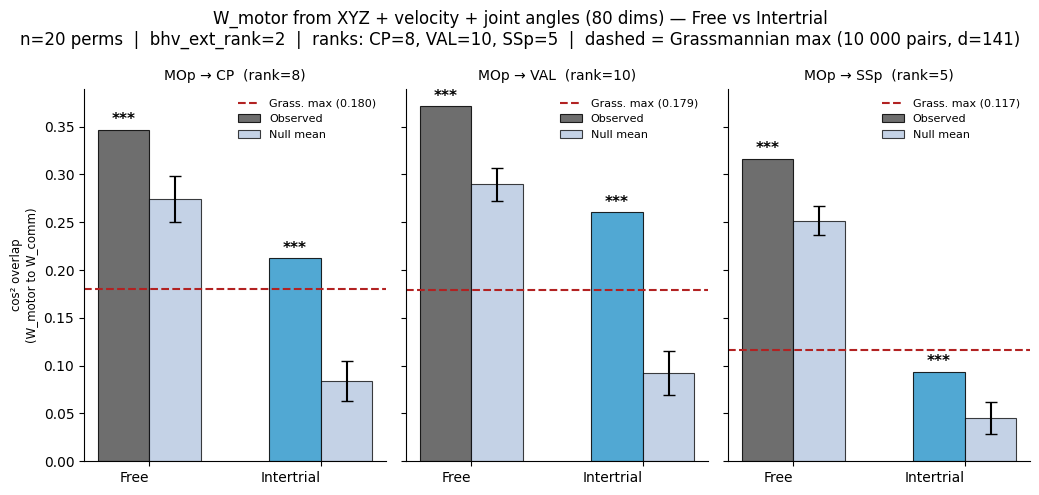

In [98]:

# --- Plot ---
fig, axes = plt.subplots(1, len(AREAS), figsize=(3.5 * len(AREAS), 5), sharey=True)
cond_colors_ext = ['#555555', '#3399cc']

for ax, area in zip(axes, AREAS):
    obs_vals = [res[area]['overlap']     for res in [results_free_ext, results_intertrial_ext]]
    null_m   = [res[area]['null'].mean() for res in [results_free_ext, results_intertrial_ext]]
    null_s   = [res[area]['null'].std()  for res in [results_free_ext, results_intertrial_ext]]
    ps       = [res[area]['p']           for res in [results_free_ext, results_intertrial_ext]]
    zs       = [res[area]['z']           for res in [results_free_ext, results_intertrial_ext]]

    x = np.arange(2)
    w = 0.3

    ax.bar(x - w/2, obs_vals, w, color=cond_colors_ext, alpha=0.85, edgecolor='k', lw=0.8, label='Observed')
    ax.bar(x + w/2, null_m,   w, color='lightsteelblue',  alpha=0.75, edgecolor='k', lw=0.8, label='Null mean')
    ax.errorbar(x + w/2, null_m, yerr=null_s, fmt='none', color='k', capsize=4, lw=1.5)

    ax.axhline(grass_ext[area], color='firebrick', lw=1.5, ls='--',
               label=f'Grass. max ({grass_ext[area]:.3f})')

    for i, (ob, p, z) in enumerate(zip(obs_vals, ps, zs)):
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.'))
        ax.text(x[i] - w/2, ob + 0.003, sig, ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(['Free', 'Intertrial'], fontsize=None, rotation=0, ha='right')
    ax.set_title(f"MOp → {area}  (rank={optimal_ranks[area]})", fontsize=10)
    ax.set_ylabel("cos² overlap\n(W_motor to W_comm)" if area == AREAS[0] else "", fontsize=8.5)
    ax.legend(fontsize=8, frameon=False)
    sns.despine(ax=ax)

plt.suptitle(
    f"W_motor from XYZ + velocity + joint angles (80 dims) — Free vs Intertrial\n"
    f"n={N_PERMS_EXT} perms  |  bhv_ext_rank={optimal_ranks['bhv_ext']}  |  "
    f"ranks: {', '.join(f'{a}={optimal_ranks[a]}' for a in AREAS)}"
    f"  |  dashed = Grassmannian max (10 000 pairs, d={d_ext})",
    # fontsize=9, y=1.02,
)
plt.tight_layout()
plt.show()

# Motor potent subspace 80 dims allignment. 
Null shuffle of free is run using pseudotrials of intertrial

In [17]:

# ── Cross-condition null: Free observed vs null W_comm drawn from Intertrial area ──
# Observed : W_motor (Free MOp → bhv_ext) and W_comm (Free MOp → area) — same as before.
# Null     : W_motor kept fixed; W_comm is re-estimated by replacing the Free area signal
#            with rows randomly sampled from the Intertrial area signal.
#
# Rationale: if the within-Free null is inflated because locomotion dominates MOp
# (observed and null W_comm both converge to the same locomotion axis → cos² ≈ 1),
# then swapping in Intertrial area rows (lower locomotion-related variance) should
# lower the null and recover a significant z-score for Free.

N_PERMS_CROSS = 20


def run_fixed_motor_cross_null(td_obs, td_null_src, window, area_list, opt_ranks,
                                n_perms, label, bhv_signal='bhv_ext'):
    """
    Observed W_motor + W_comm from td_obs.
    Null: W_motor fixed; W_comm re-estimated with MOp from td_obs but area signal
    randomly sampled (with replacement) from td_null_src.
    """
    res = {}
    bhv_rank = opt_ranks[bhv_signal]

    W_motor_cond, _ = compute_embedding_on_td(
        td_obs,
        signal_x='MOp_rates_pca',
        signal_y=bhv_signal,
        model=subspaces.ReducedRankCommSubspace(rank=bhv_rank),
        window=window,
    )
    print(f"[{label}] W_motor ({bhv_signal}) estimated  (rank={bhv_rank}, shape={W_motor_cond.shape})")

    null_pool = {a: td_null_src[f'{a}_rates_pca'].values.copy() for a in area_list}
    N_obs = len(td_obs)

    for area in area_list:
        opt_rank = opt_ranks[area]

        W_comm_obs, _ = compute_embedding_on_td(
            td_obs,
            signal_x='MOp_rates_pca',
            signal_y=f'{area}_rates_pca',
            model=subspaces.ReducedRankCommSubspace(rank=opt_rank),
            window=window,
        )
        obs = subspaces.compute_overlap_between_subspaces(W_motor_cond, W_comm_obs)

        _null_sig  = null_pool[area]
        _opt_rank  = opt_rank
        _W_motor   = W_motor_cond

        def _one_perm(seed, _ns=_null_sig, _or=_opt_rank, _wm=_W_motor):
            rng_ = np.random.default_rng(seed)
            idx  = rng_.integers(0, len(_ns), size=N_obs)
            td_perm = td_obs.copy()
            td_perm[f'{area}_rates_pca'] = _ns[idx]
            W_c_null, _ = compute_embedding_on_td(
                td_perm,
                signal_x='MOp_rates_pca',
                signal_y=f'{area}_rates_pca',
                model=subspaces.ReducedRankCommSubspace(rank=_or),
                window=window,
            )
            return subspaces.compute_overlap_between_subspaces(_wm, W_c_null)

        null = np.array(Parallel(n_jobs=-1, prefer='threads')(
            delayed(_one_perm)(seed)
            for seed in tqdm(range(n_perms), desc=f'{label} | {area}', leave=True)
        ))

        p = np.mean(null >= obs)
        z = (obs - null.mean()) / null.std()
        print(f"[{label}] {area} (rank={opt_rank})  obs={obs:.4f}  null={null.mean():.4f}±{null.std():.4f}  z={z:.2f}  p={p:.4f}")
        res[area] = dict(overlap=obs, null=null, p=p, z=z, opt_rank=opt_rank, bhv_rank=bhv_rank)
    return res


results_free_cross = run_fixed_motor_cross_null(
    free_td_ext_shuff, intertrial_td_ext_shuff,
    EXT_WINDOW, AREAS, optimal_ranks, N_PERMS_CROSS,
    'Free (IT null)', bhv_signal='bhv_ext',
)


results_intertrial_cross = run_fixed_motor_cross_null(
    intertrial_td_ext_shuff, free_td_ext_shuff,
    EXT_WINDOW, AREAS, optimal_ranks, N_PERMS_CROSS,
    'Intertrial (Free null)', bhv_signal='bhv_ext',
)

[Free (IT null)] W_motor (bhv_ext) estimated  (rank=8, shape=(178, 8))


Free (IT null) | SSp: 100%|██████████| 20/20 [00:00<00:00, 60349.70it/s]


[Free (IT null)] SSp (rank=5)  obs=0.5661  null=0.5843±0.0182  z=-1.00  p=0.8000


Free (IT null) | VAL: 100%|██████████| 20/20 [00:00<00:00, 75709.46it/s]


[Free (IT null)] VAL (rank=10)  obs=0.4917  null=0.4954±0.0145  z=-0.26  p=0.7500


...

[Intertrial (Free null)] SSp (rank=5)  obs=0.2046  null=0.0737±0.0153  z=8.56  p=0.0000


Intertrial (Free null) | VAL: 100%|██████████| 20/20 [00:00<00:00, 84138.50it/s]


[Intertrial (Free null)] VAL (rank=10)  obs=0.2299  null=0.1074±0.0123  z=9.97  p=0.0000


Intertrial (Free null) | CP: 100%|██████████| 20/20 [00:00<00:00, 83886.08it/s]


[Intertrial (Free null)] CP (rank=8)  obs=0.2006  null=0.0803±0.0156  z=7.72  p=0.0000


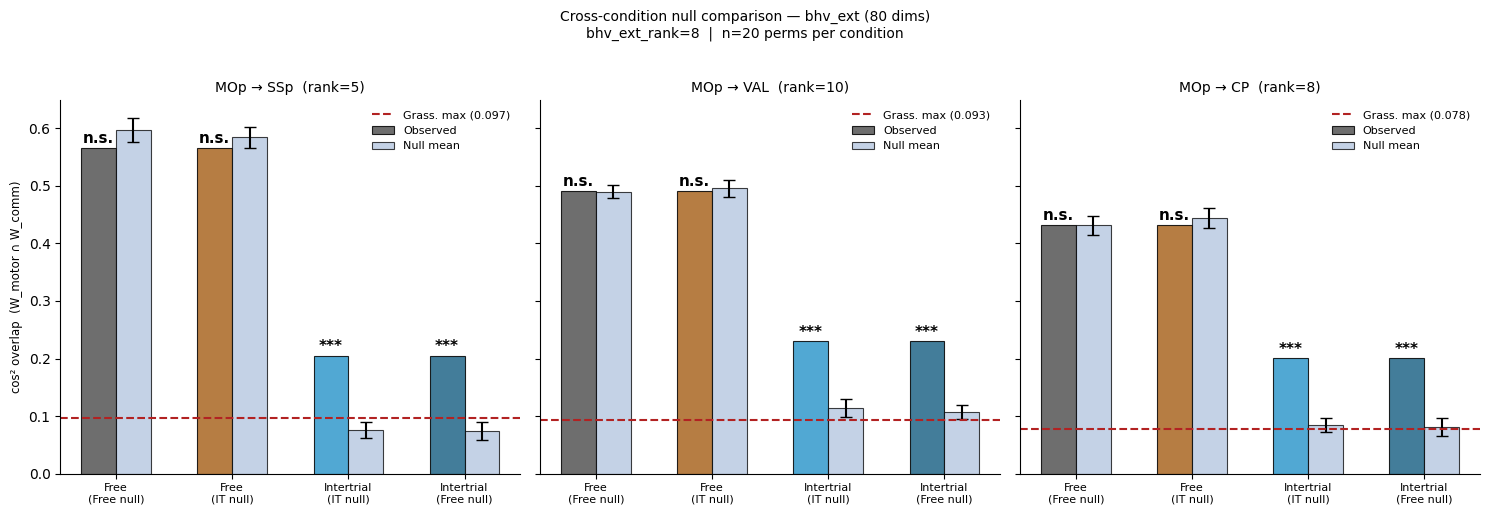

In [23]:

# ── Plot: 4-panel comparison per area ────────────────────────────────────────
# Col 1: Free observed vs within-Free null        (original, inflated null)
# Col 2: Free observed vs cross-IT null           (Free MOp, IT area as null)
# Col 3: Intertrial observed vs within-IT null    (original, reference)
# Col 4: Intertrial observed vs cross-Free null   (IT MOp, Free area as null)

CONDITIONS_4   = ['Free\n(Free null)', 'Free\n(IT null)', 'Intertrial\n(IT null)', 'Intertrial\n(Free null)']
results_list_4 = [results_free_ext, results_free_cross, results_intertrial_ext, results_intertrial_cross]
cond_colors_4  = ['#555555', '#aa6622', '#3399cc', '#226688']

fig, axes = plt.subplots(1, len(AREAS), figsize=(5 * len(AREAS), 5), sharey=True)

for ax, area in zip(axes, AREAS):
    obs_vals = [r[area]['overlap']    for r in results_list_4]
    null_m   = [r[area]['null'].mean() for r in results_list_4]
    null_s   = [r[area]['null'].std()  for r in results_list_4]
    ps       = [r[area]['p']           for r in results_list_4]
    zs       = [r[area]['z']           for r in results_list_4]

    x = np.arange(len(CONDITIONS_4))
    w = 0.3

    ax.bar(x - w/2, obs_vals, w, color=cond_colors_4, alpha=0.85, edgecolor='k', lw=0.8, label='Observed')
    ax.bar(x + w/2, null_m,   w, color='lightsteelblue', alpha=0.75, edgecolor='k', lw=0.8, label='Null mean')
    ax.errorbar(x + w/2, null_m, yerr=null_s, fmt='none', color='k', capsize=4, lw=1.5)

    ax.axhline(grass_ext[area], color='firebrick', lw=1.5, ls='--',
               label=f'Grass. max ({grass_ext[area]:.3f})')

    for i, (ob, p, z) in enumerate(zip(obs_vals, ps, zs)):
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.'))
        ax.text(x[i] - w/2, ob + 0.003, sig, ha='center', va='bottom', fontsize=11, fontweight='bold')
        # ax.text(x[i],        -0.01,      f'z={z:.1f}', ha='center', va='top', fontsize=7, color='dimgray')

    ax.set_xticks(x)
    ax.set_xticklabels(CONDITIONS_4, fontsize=8)
    ax.set_title(f"MOp → {area}  (rank={optimal_ranks[area]})", fontsize=10)
    ax.set_ylabel("cos² overlap  (W_motor ∩ W_comm)" if area == AREAS[0] else "", fontsize=8.5)
    ax.legend(fontsize=8, frameon=False)
    sns.despine(ax=ax)

plt.suptitle(
    f"Cross-condition null comparison — bhv_ext (80 dims)\n"
    f"bhv_ext_rank={optimal_ranks['bhv_ext']}  |  n={N_PERMS_CROSS} perms per condition",
    fontsize=10, y=1.02,
)
plt.tight_layout()
plt.show()


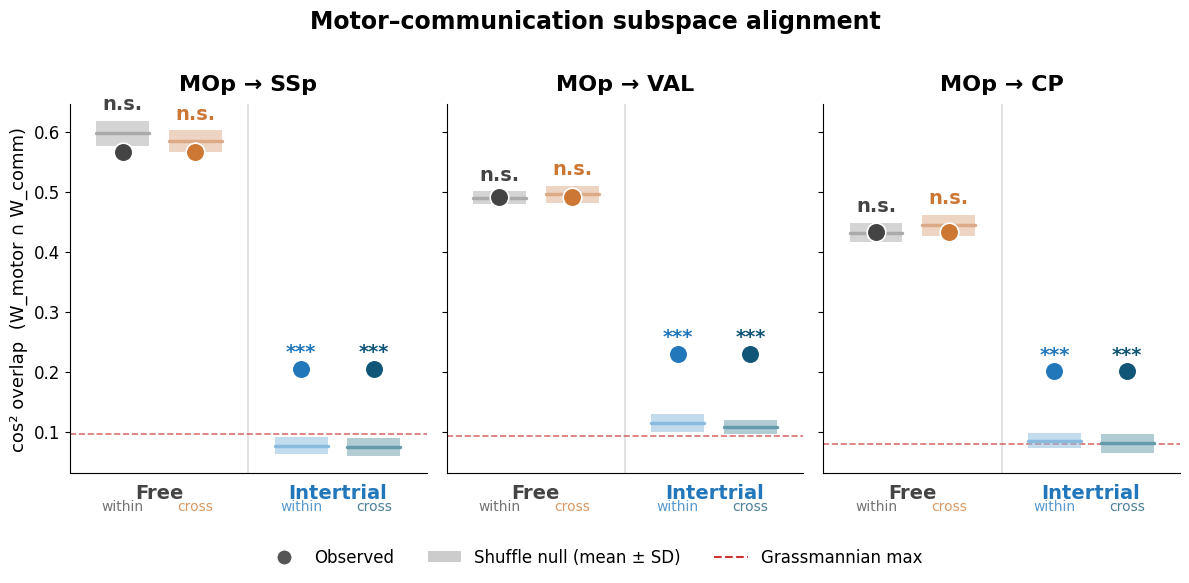

In [34]:

# ── Presentation version: cross-condition null comparison ─────────────────────
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

RESULTS_4  = [results_free_ext, results_free_cross, results_intertrial_ext, results_intertrial_cross]
DOT_COLORS = ['#444444', '#cc7733', '#2277bb', '#115577']
NULL_COLORS= ['#aaaaaa', '#ddaa88', '#88bbdd', '#669aaa']

# Two tight pairs with a clear gap between conditions
xs = np.array([0.0, 0.55, 1.35, 1.90])

fig, axes = plt.subplots(1, len(AREAS), figsize=(4.0 * len(AREAS), 5.5), sharey=True)
fig.subplots_adjust(wspace=0.08)

for ax, area in zip(axes, AREAS):
    ax.axhline(grass_ext[area], color='#cc3333', lw=1.2, ls='--', zorder=1, alpha=0.7)

    for xi, (res, dc, nc) in enumerate(zip(RESULTS_4, DOT_COLORS, NULL_COLORS)):
        obs = res[area]['overlap']
        nm  = res[area]['null'].mean()
        nsd = res[area]['null'].std()
        p   = res[area]['p']
        x   = xs[xi]

        # Null band
        ax.fill_between([x - 0.20, x + 0.20], nm - nsd, nm + nsd,
                        color=nc, alpha=0.5, zorder=2, linewidth=0)
        ax.plot([x - 0.20, x + 0.20], [nm, nm], color=nc, lw=2.5,
                solid_capstyle='round', zorder=3)

        # Observed dot — bigger for a talk
        ax.scatter(x, obs, s=180, color=dc, zorder=5, edgecolors='white', linewidths=1.2)

        # Significance
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.'))
        y_top = max(obs, nm + nsd) + 0.012
        ax.text(x, y_top, sig, ha='center', va='bottom', fontsize=14,
                fontweight='bold', color=dc)

    # Divider between conditions
    ax.axvline((xs[1] + xs[2]) / 2, color='#dddddd', lw=1.2, zorder=0)

    # Condition labels above x-axis (replacing cluttered tick labels)
    ax.set_xticks([])
    for cond_str, xc, col in [
        ('Free',       (xs[0] + xs[1]) / 2, '#444444'),
        ('Intertrial', (xs[2] + xs[3]) / 2, '#2277bb'),
    ]:
        ax.text(xc, -0.028, cond_str, ha='center', va='top',
                fontsize=14, fontweight='bold', color=col,
                transform=ax.get_xaxis_transform())

    # "within / cross" sub-labels directly under dots
    for xi_sub, sublabel in enumerate(['within', 'cross', 'within', 'cross']):
        ax.text(xs[xi_sub], -0.07, sublabel, ha='center', va='top',
                fontsize=10, color=DOT_COLORS[xi_sub], alpha=0.75,
                transform=ax.get_xaxis_transform())

    ax.set_xlim(xs[0] - 0.40, xs[-1] + 0.40)
    ax.set_title(f"MOp → {area}", fontsize=16, pad=10, fontweight='semibold')
    if area == AREAS[0]:
        ax.set_ylabel("cos² overlap  (W_motor ∩ W_comm)", fontsize=13)
    ax.yaxis.set_tick_params(labelsize=12)
    sns.despine(ax=ax)

# ── Legend ────────────────────────────────────────────────────────────────────
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#555555',
           markersize=11, label='Observed'),
    Patch(facecolor='#aaaaaa', alpha=0.6, label='Shuffle null (mean ± SD)'),
    Line2D([0], [0], color='#cc3333', lw=1.5, ls='--', label='Grassmannian max'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=12,
           frameon=False, bbox_to_anchor=(0.5, -0.02))

fig.suptitle("Motor–communication subspace alignment",
             fontsize=17, fontweight='bold', y=1.02)

plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.show()

mpl.rcParams.update(mpl.rcParamsDefault)


In [48]:

# ── Variance in MOp captured by W_motor and W_comm ────────────────────────────
# For both conditions: how much of MOp variance sits in the motor-potent subspace
# vs the communication subspace to each area?
# Within-cond null: shuffle area signal × N_PERMS_VAF → variance distribution.
# Cross-cond null:  replace area signal with rows from the other condition.

from tools.subspaces.utils import variance_in_subspace_df

N_PERMS_VAF = 20

cond_tds = {
    'Free':       free_td_ext_shuff,
    'Intertrial': intertrial_td_ext_shuff,
}

vaf_res = {}   # cond → {'motor': float, 'total': float, 'areas': {area: {...}}}

for cond_label, td in cond_tds.items():
    mop_all   = np.concatenate(td['MOp_rates_pca'].values)
    total_var = np.trace(np.cov(mop_all.T))

    W_m, vaf_motor = compute_embedding_on_td(
        td, signal_x='MOp_rates_pca', signal_y='bhv_ext',
        model=subspaces.ReducedRankCommSubspace(rank=optimal_ranks['bhv_ext']),
        window=EXT_WINDOW,
    )
    vaf_res[cond_label] = {'motor': vaf_motor, 'total': total_var, 'areas': {}}

    for area in AREAS:
        W_c, vaf_obs = compute_embedding_on_td(
            td, signal_x='MOp_rates_pca', signal_y=f'{area}_rates_pca',
            model=subspaces.ReducedRankCommSubspace(rank=optimal_ranks[area]),
            window=EXT_WINDOW,
        )

        # Within-condition null
        area_sig = td[f'{area}_rates_pca'].values.copy()
        rng_vaf  = np.random.default_rng(0)
        null_vafs = []
        for _ in range(N_PERMS_VAF):
            td_p = td.copy()
            td_p[f'{area}_rates_pca'] = area_sig[rng_vaf.permutation(len(td))]
            _, vn = compute_embedding_on_td(
                td_p, signal_x='MOp_rates_pca', signal_y=f'{area}_rates_pca',
                model=subspaces.ReducedRankCommSubspace(rank=optimal_ranks[area]),
                window=EXT_WINDOW,
            )
            null_vafs.append(vn)
        null_vafs = np.array(null_vafs)

        vaf_res[cond_label]['areas'][area] = {'obs': vaf_obs, 'null': null_vafs}
        print(f"[{cond_label}] total={total_var:.2f}  W_motor={vaf_motor:.3f} ({100*vaf_motor/total_var:.1f}%)  "
              f"{area} W_comm obs={vaf_obs:.3f} ({100*vaf_obs/total_var:.1f}%)  "
              f"within-null={null_vafs.mean():.3f}±{null_vafs.std():.3f}")

# ── Cross-condition null VAF ───────────────────────────────────────────────────
cross_td_pairs = {
    'Free':       (free_td_ext_shuff,       intertrial_td_ext_shuff),
    'Intertrial': (intertrial_td_ext_shuff, free_td_ext_shuff),
}
for cond_label, (td_obs, td_null_src) in cross_td_pairs.items():
    total = vaf_res[cond_label]['total']
    for area in AREAS:
        area_sig_null = td_null_src[f'{area}_rates_pca'].values.copy()
        N_obs         = len(td_obs)
        rng_cross     = np.random.default_rng(1)
        cross_vafs    = []
        for _ in range(N_PERMS_VAF):
            td_p = td_obs.copy()
            idx  = rng_cross.integers(0, len(area_sig_null), size=N_obs)
            td_p[f'{area}_rates_pca'] = area_sig_null[idx]
            _, vn = compute_embedding_on_td(
                td_p, signal_x='MOp_rates_pca', signal_y=f'{area}_rates_pca',
                model=subspaces.ReducedRankCommSubspace(rank=optimal_ranks[area]),
                window=EXT_WINDOW,
            )
            cross_vafs.append(vn)
        cross_vafs = np.array(cross_vafs)
        vaf_res[cond_label]['areas'][area]['cross_null'] = cross_vafs
        print(f"[{cond_label}] {area}  cross-null={cross_vafs.mean():.3f}±{cross_vafs.std():.3f} "
              f"({100*cross_vafs.mean()/total:.1f}%)")


[Free] total=6814.78  W_motor=132.482 (1.9%)  SSp W_comm obs=31.576 (0.5%)  within-null=10.139±1.591
[Free] total=6814.78  W_motor=132.482 (1.9%)  VAL W_comm obs=59.283 (0.9%)  within-null=19.820±1.346
[Free] total=6814.78  W_motor=132.482 (1.9%)  CP W_comm obs=87.099 (1.3%)  within-null=23.399±2.218
[Intertrial] total=9415.51  W_motor=395.538 (4.2%)  SSp W_comm obs=348.005 (3.7%)  within-null=91.368±4.357
[Intertrial] total=9415.51  W_motor=395.538 (4.2%)  VAL W_comm obs=386.834 (4.1%)  within-null=137.765±3.291
[Intertrial] total=9415.51  W_motor=395.538 (4.2%)  CP W_comm obs=449.267 (4.8%)  within-null=129.424±3.734
[Free] SSp  cross-null=13.009±2.021 (0.2%)
[Free] VAL  cross-null=19.263±1.360 (0.3%)
[Free] CP  cross-null=19.868±1.800 (0.3%)
[Intertrial] SSp  cross-null=85.462±3.691 (0.9%)
[Intertrial] VAL  cross-null=142.813±5.430 (1.5%)
[Intertrial] CP  cross-null=140.266±6.104 (1.5%)


NameError: name 'vaf_res' is not defined

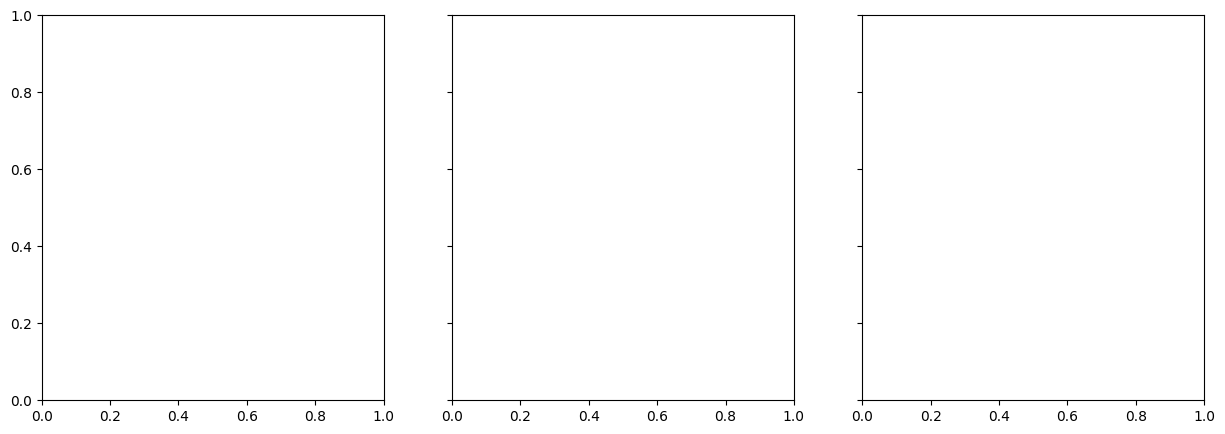

In [18]:

# ── Plot: variance in MOp captured by W_motor and W_comm ─────────────────────
# Each area panel: grouped bars for Free (left) and Intertrial (right).
# Within each group (left to right):
#   W_motor (solid) | W_comm obs (hatched) | within-cond null (blue) | cross-cond null (salmon)
# Y-axis: fraction of total MOp variance (%).

from matplotlib.patches import Patch

cond_list       = ['Free', 'Intertrial']
cond_colors_vaf = {'Free': '#555555', 'Intertrial': '#3399cc'}
group_gap = 1.3
bar_w     = 0.22

fig, axes = plt.subplots(1, len(AREAS), figsize=(5 * len(AREAS), 5), sharey=True)

for ax, area in zip(axes, AREAS):
    for gi, cond in enumerate(cond_list):
        total      = vaf_res[cond]['total']
        v_mot      = 100 * vaf_res[cond]['motor'] / total
        v_obs      = 100 * vaf_res[cond]['areas'][area]['obs'] / total
        null_arr   = 100 * vaf_res[cond]['areas'][area]['null'] / total
        cross_arr  = 100 * vaf_res[cond]['areas'][area]['cross_null'] / total

        c  = cond_colors_vaf[cond]
        x0 = gi * group_gap

        ax.bar(x0 - 1.5*bar_w, v_mot,           bar_w, color=c,              alpha=0.85, edgecolor='k', lw=0.8)
        ax.bar(x0 - 0.5*bar_w, v_obs,           bar_w, color=c,              alpha=0.5,  edgecolor='k', lw=0.8, hatch='//')
        ax.bar(x0 + 0.5*bar_w, null_arr.mean(), bar_w, color='lightsteelblue', alpha=0.9, edgecolor='k', lw=0.8)
        ax.errorbar(x0 + 0.5*bar_w, null_arr.mean(),  yerr=null_arr.std(),  fmt='none', color='k', capsize=3, lw=1.2)
        ax.bar(x0 + 1.5*bar_w, cross_arr.mean(),bar_w, color='lightsalmon',   alpha=0.9, edgecolor='k', lw=0.8)
        ax.errorbar(x0 + 1.5*bar_w, cross_arr.mean(), yerr=cross_arr.std(), fmt='none', color='k', capsize=3, lw=1.2)

    ax.set_xticks([i * group_gap for i in range(len(cond_list))])
    ax.set_xticklabels(cond_list, fontsize=10)
    ax.set_title(f"MOp → {area}  (rank={optimal_ranks[area]})", fontsize=10)
    ax.set_ylabel("MOp variance in subspace (%)" if area == AREAS[0] else "", fontsize=9)
    sns.despine(ax=ax)

legend_handles = [
    Patch(facecolor='#555555', alpha=0.85, edgecolor='k',            label='Free – W_motor'),
    Patch(facecolor='#555555', alpha=0.5,  edgecolor='k', hatch='//', label='Free – W_comm obs'),
    Patch(facecolor='#3399cc', alpha=0.85, edgecolor='k',            label='IT – W_motor'),
    Patch(facecolor='#3399cc', alpha=0.5,  edgecolor='k', hatch='//', label='IT – W_comm obs'),
    Patch(facecolor='lightsteelblue', alpha=0.9, edgecolor='k',      label='Within-cond null (mean±sd)'),
    Patch(facecolor='lightsalmon',    alpha=0.9, edgecolor='k',      label='Cross-cond null (mean±sd)'),
]
fig.legend(handles=legend_handles, fontsize=8.5, frameon=False,
           loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.14))

plt.suptitle(
    f"MOp variance captured by W_motor (bhv_ext, rank={optimal_ranks['bhv_ext']}) "
    f"and W_comm (per area)\nFree vs Intertrial  |  null = {N_PERMS_VAF} shuffles of area signal",
    fontsize=10, y=1.0,
)
plt.tight_layout()
plt.show()
